In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set a seed for reproducibility
np.random.seed(42)

# Simulate 10,000 fair coin flips: 0 = tails, 1 = heads
n_flips = 10000
flips = np.random.randint(0, 2, size=n_flips)

# Theoretical probability of heads
theoretical_p = 0.5

# Empirical probability after all flips
empirical_p = flips.mean()  # mean of 0s and 1s = proportion of 1s (heads)

print(f"Theoretical P(heads): {theoretical_p}")
print(f"Empirical P(heads) after {n_flips} flips: {empirical_p:.4f}")

Theoretical P(heads): 0.5
Empirical P(heads) after 10000 flips: 0.4987


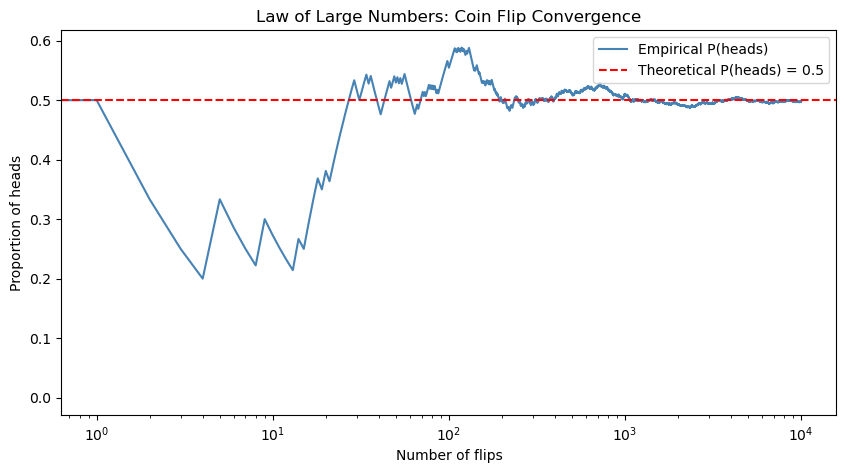

In [7]:
# Running (cumulative) average of heads proportion after each flip
running_avg = np.cumsum(flips) / np.arange(1, n_flips + 1)

plt.figure(figsize=(10, 5))
plt.plot(running_avg, label='Empirical P(heads)', color='steelblue')
plt.axhline(y=theoretical_p, color='red', linestyle='--', label='Theoretical P(heads) = 0.5')
plt.xlabel('Number of flips')
plt.ylabel('Proportion of heads')
plt.title('Law of Large Numbers: Coin Flip Convergence')
plt.legend()
plt.xscale('log')  # log scale shows early volatility + later convergence nicely
plt.show()

In [10]:
# Simulate 10,000 rolls of a fair six-sided die
n_rolls = 10000
rolls = np.random.randint(1, 7, size=n_rolls)  # 1 to 6 inclusive

# Theoretical probability of each face
theoretical_probs = {face: 1/6 for face in range(1, 7)}

# Empirical probabilities
unique, counts = np.unique(rolls, return_counts=True)
empirical_probs = dict(zip(unique, counts / n_rolls))

print("Face | Theoretical | Empirical")
for face in range(1, 7):
    print(f"{face}    | {theoretical_probs[face]:.4f}      | {empirical_probs[face]:.4f}")

Face | Theoretical | Empirical
1    | 0.1667      | 0.1614
2    | 0.1667      | 0.1606
3    | 0.1667      | 0.1664
4    | 0.1667      | 0.1689
5    | 0.1667      | 0.1801
6    | 0.1667      | 0.1626


In [11]:
n_pairs = 100000
die1 = np.random.randint(1, 7, size=n_pairs)
die2 = np.random.randint(1, 7, size=n_pairs)

# Event A: first die is even
A = (die1 % 2 == 0)
# Event B: sum equals 7
B = (die1 + die2 == 7)

p_A = A.mean()
p_B = B.mean()
p_A_and_B = (A & B).mean()
p_A_given_B = p_A_and_B / p_B

print(f"P(A) = {p_A:.4f}")
print(f"P(A|B) = {p_A_given_B:.4f}")
print(f"Independent? P(A) ≈ P(A|B): {np.isclose(p_A, p_A_given_B, atol=0.02)}")

P(A) = 0.5016
P(A|B) = 0.5082
Independent? P(A) ≈ P(A|B): True
